In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
print("All libraries loaded ✅")

All libraries loaded ✅


In [4]:
# Load raw data
df = pd.read_csv('bigmart.csv')

# Cleaning from Project 1
df['FatContent'] = df['FatContent'].replace({
    'low fat': 'Low Fat',
    'LF'     : 'Low Fat',
    'reg'    : 'Regular'
})

df['Weight'] = df.groupby('ProductType')['Weight'].transform(
    lambda x: x.fillna(x.median())
)

df['OutletSize'] = df.groupby('OutletType')['OutletSize'].transform(
    lambda x: x.fillna(x.mode()[0])
)

df['OutletAge'] = 2025 - df['EstablishmentYear']

print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Ready ✅")

Shape: (8523, 13)
Missing values: 0
Ready ✅


In [5]:
# Columns we will use to predict OutletSales
features = [
    'MRP',
    'OutletAge',
    'ProductVisibility',
    'Weight',
    'FatContent',
    'OutletSize',
    'OutletType',
    'LocationType',
    'ProductType'
]

# Target column we want to predict
target = 'OutletSales'

print("Input features:", features)
print("\nTarget:", target)

Input features: ['MRP', 'OutletAge', 'ProductVisibility', 'Weight', 'FatContent', 'OutletSize', 'OutletType', 'LocationType', 'ProductType']

Target: OutletSales


In [6]:
# ML cannot read text — convert categories to numbers
df_ml = df[features + [target]].copy()

# Apply LabelEncoder to each text column
le = LabelEncoder()
categorical_cols = ['FatContent', 'OutletSize', 
                    'OutletType', 'LocationType', 'ProductType']

for col in categorical_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

print("After encoding:")
print(df_ml.head())
print("\nData types:")
print(df_ml.dtypes)

After encoding:
        MRP  OutletAge  ProductVisibility  Weight  FatContent  OutletSize  \
0  249.8092         26           0.016047    9.30           0           1   
1   48.2692         16           0.019278    5.92           1           1   
2  141.6180         26           0.016760   17.50           0           1   
3  182.0950         27           0.000000   19.20           1           2   
4   53.8614         38           0.000000    8.93           0           0   

   OutletType  LocationType  ProductType  OutletSales  
0           1             0            4    3735.1380  
1           2             2           14     443.4228  
2           1             0           10    2097.2700  
3           0             2            6     732.3800  
4           1             2            9     994.7052  

Data types:
MRP                  float64
OutletAge              int64
ProductVisibility    float64
Weight               float64
FatContent             int64
OutletSize             int6

In [7]:
# Separate inputs and target
X = df_ml[features]
y = df_ml[target]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Total rows      :", len(df_ml))
print("Training rows   :", len(X_train))
print("Testing rows    :", len(X_test))

Total rows      : 8523
Training rows   : 6818
Testing rows    : 1705


In [8]:
# Build and train Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict on test set
lr_pred = lr_model.predict(X_test)

# Evaluate
lr_mae  = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2   = r2_score(y_test, lr_pred)

print("=== Linear Regression ===")
print(f"MAE  : {lr_mae:.2f}")
print(f"RMSE : {lr_rmse:.2f}")
print(f"R2   : {lr_r2:.2f}")

=== Linear Regression ===
MAE  : 856.21
RMSE : 1143.04
R2   : 0.52


In [9]:
# Build and train Decision Tree
dt_model = DecisionTreeRegressor(max_depth=6, random_state=42)
dt_model.fit(X_train, y_train)

# Predict
dt_pred = dt_model.predict(X_test)

# Evaluate
dt_mae  = mean_absolute_error(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_r2   = r2_score(y_test, dt_pred)

print("=== Decision Tree ===")
print(f"MAE  : {dt_mae:.2f}")
print(f"RMSE : {dt_rmse:.2f}")
print(f"R2   : {dt_r2:.2f}")

=== Decision Tree ===
MAE  : 727.02
RMSE : 1045.80
R2   : 0.60


In [10]:
# Build and train Random Forest
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)
rf_model.fit(X_train, y_train)

# Predict
rf_pred = rf_model.predict(X_test)

# Evaluate
rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2   = r2_score(y_test, rf_pred)

print("=== Random Forest ===")
print(f"MAE  : {rf_mae:.2f}")
print(f"RMSE : {rf_rmse:.2f}")
print(f"R2   : {rf_r2:.2f}")

=== Random Forest ===
MAE  : 725.74
RMSE : 1037.05
R2   : 0.60


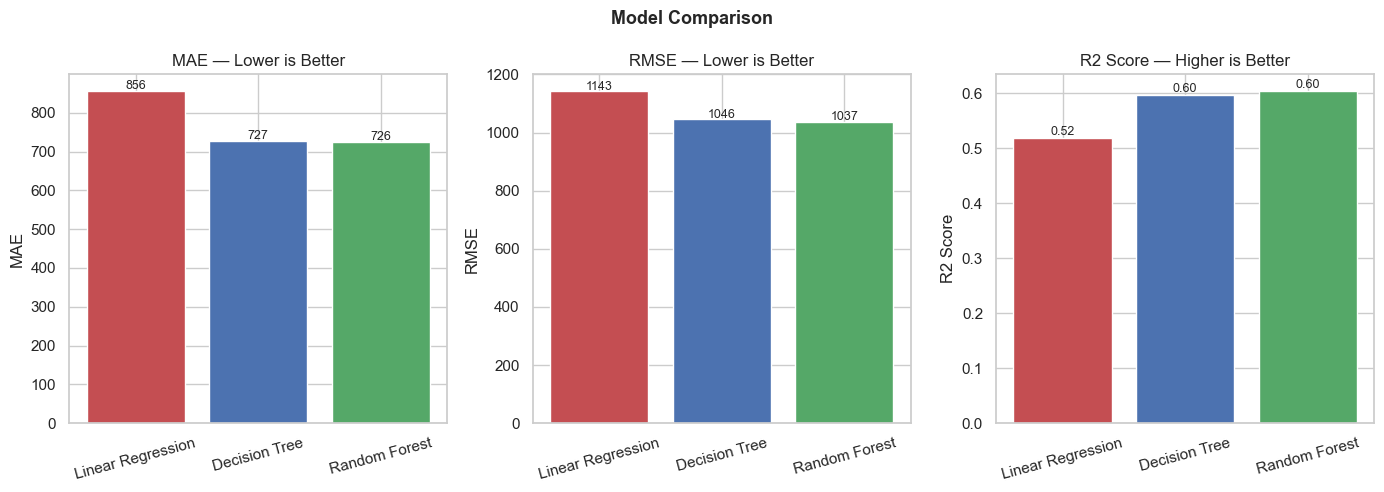

In [11]:
# Visual comparison of all three models
models  = ['Linear Regression', 'Decision Tree', 'Random Forest']
mae     = [lr_mae,  dt_mae,  rf_mae]
rmse    = [lr_rmse, dt_rmse, rf_rmse]
r2      = [lr_r2,   dt_r2,   rf_r2]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# MAE
axes[0].bar(models, mae, color=['#C44E52','#4C72B0','#55A868'], edgecolor='white')
axes[0].set_title('MAE — Lower is Better')
axes[0].set_ylabel('MAE')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(mae):
    axes[0].text(i, v + 5, f'{v:.0f}', ha='center', fontsize=9)

# RMSE
axes[1].bar(models, rmse, color=['#C44E52','#4C72B0','#55A868'], edgecolor='white')
axes[1].set_title('RMSE — Lower is Better')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(rmse):
    axes[1].text(i, v + 5, f'{v:.0f}', ha='center', fontsize=9)

# R2
axes[2].bar(models, r2, color=['#C44E52','#4C72B0','#55A868'], edgecolor='white')
axes[2].set_title('R2 Score — Higher is Better')
axes[2].set_ylabel('R2 Score')
axes[2].tick_params(axis='x', rotation=15)
for i, v in enumerate(r2):
    axes[2].text(i, v + 0.005, f'{v:.2f}', ha='center', fontsize=9)

plt.suptitle('Model Comparison', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

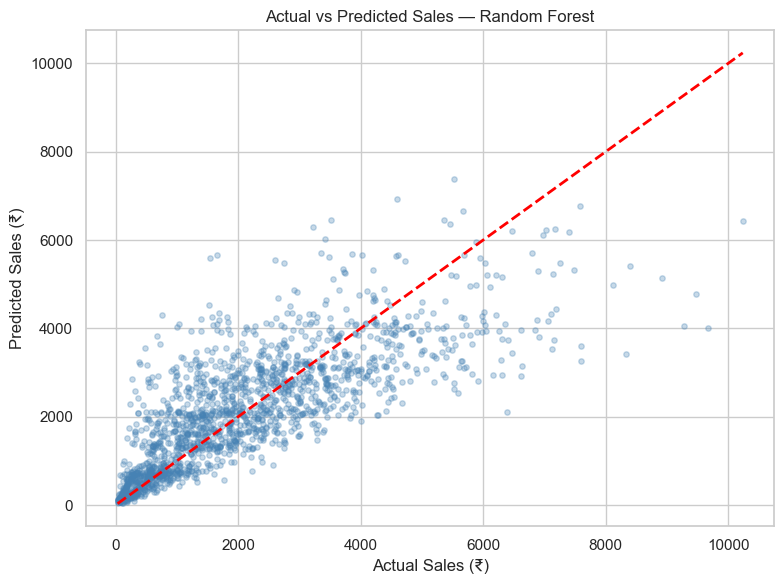

In [12]:
# Actual vs Predicted — Random Forest (best model)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_pred, alpha=0.3, color='steelblue', s=15)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2, linestyle='--')

plt.title('Actual vs Predicted Sales — Random Forest')
plt.xlabel('Actual Sales (₹)')
plt.ylabel('Predicted Sales (₹)')
plt.tight_layout()
plt.show()

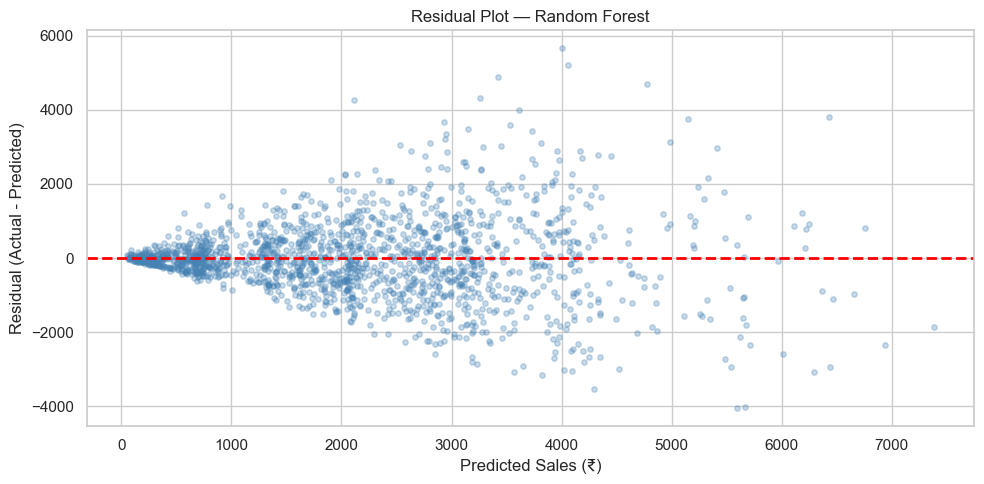

Mean Residual: -28.06


In [14]:
# Residual = Actual - Predicted
residuals = y_test - rf_pred

plt.figure(figsize=(10, 5))
plt.scatter(rf_pred, residuals, alpha=0.3, color='steelblue', s=15)
plt.axhline(y=0, color='red', linewidth=2, linestyle='--')

plt.title('Residual Plot — Random Forest')
plt.xlabel('Predicted Sales (₹)')
plt.ylabel('Residual (Actual - Predicted)')
plt.tight_layout()
plt.show()

print(f"Mean Residual: {residuals.mean():.2f}")

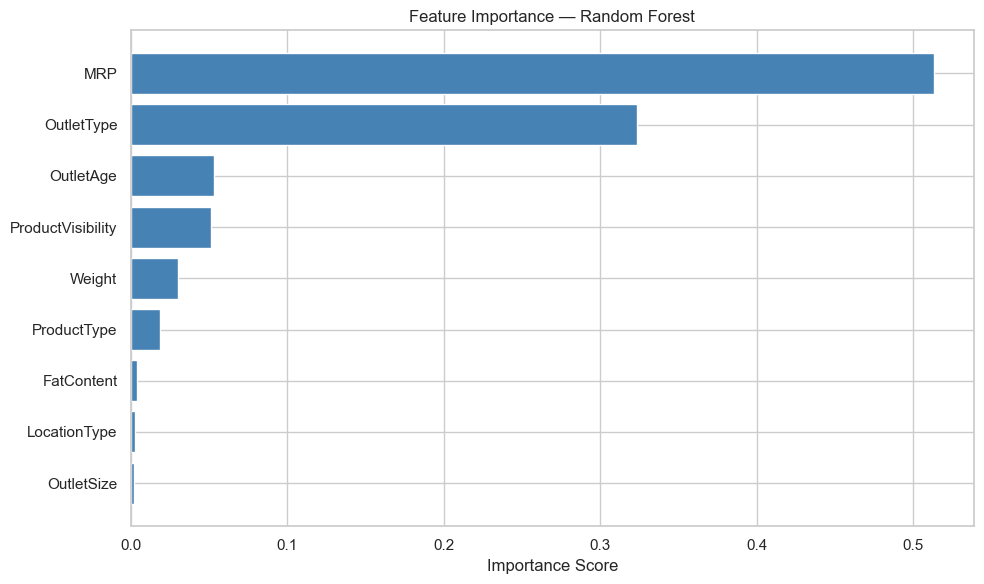

             Feature  Importance
0                MRP    0.513209
6         OutletType    0.323814
1          OutletAge    0.053027
2  ProductVisibility    0.051236
3             Weight    0.030505
8        ProductType    0.019078
4         FatContent    0.003853
7       LocationType    0.002819
5         OutletSize    0.002458


In [15]:
# Which features influenced predictions most?
importance = pd.DataFrame({
    'Feature'  : features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importance['Feature'], importance['Importance'],
         color='steelblue', edgecolor='white')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(importance.sort_values('Importance', ascending=False))

In [16]:
# Final model comparison table
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'MAE'  : [lr_mae,  dt_mae,  rf_mae],
    'RMSE' : [lr_rmse, dt_rmse, rf_rmse],
    'R2'   : [lr_r2,   dt_r2,   rf_r2]
}).round(2)

print("=== FINAL MODEL COMPARISON ===")
print(results.to_string(index=False))

print("""
WINNER → Random Forest
REASON → Lowest MAE and RMSE, highest R2

KEY FINDINGS:
- MRP is the strongest predictor of sales
- OutletType heavily influences predictions
- OutletSize contributes least to predictions
- Model explains 60% of sales variation
- Average prediction error = ₹726
""")

=== FINAL MODEL COMPARISON ===
            Model    MAE    RMSE   R2
Linear Regression 856.21 1143.04 0.52
    Decision Tree 727.02 1045.80 0.60
    Random Forest 725.74 1037.05 0.60

WINNER → Random Forest
REASON → Lowest MAE and RMSE, highest R2

KEY FINDINGS:
- MRP is the strongest predictor of sales
- OutletType heavily influences predictions
- OutletSize contributes least to predictions
- Model explains 60% of sales variation
- Average prediction error = ₹726

